Import Python modules

In [4]:
from Bio import SeqIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
import lzma
from collections import defaultdict

import os
import re
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(font_scale=1.0, style='ticks', palette='colorblind')

Make plots of how many sequences passed the alignment curation step.

In [5]:
# Iterate over log files and extract summary statistics
nseqs = defaultdict(list)
segment_dirs = [d for d in os.listdir('../logs/') if os.path.isdir(os.path.join('../logs/', d))]
for segment in segment_dirs:
    subtype_dirs = [d for d in os.listdir(f'../logs/{segment}/') if os.path.isdir(os.path.join(f'../logs/{segment}/', d))]
    for subtype in subtype_dirs:
        log_file = f'../logs/{segment}/{subtype}/curate_and_extract_coding_seqs.log'

        # Read log file
        with open(log_file, 'r') as f:
            log_content = f.read()

        # Parse results from log file using regex
        total_match = re.search(r'Total sequences processed: ([\d,]+)', log_content)
        passed_match = re.search(r'Passed quality filters: ([\d,]+)', log_content)
        failed_match = re.search(r'Failed quality filters: ([\d,]+)', log_content)

        nseqs['segment_subtype'].append(f'{segment}_{subtype}')
        nseqs['total'].append(int(total_match.group(1).replace(',', '')))
        nseqs['passed'].append(int(passed_match.group(1).replace(',', '')))
        nseqs['failed'].append(int(failed_match.group(1).replace(',', '')))

nseqs_df = pd.DataFrame(nseqs)
nseqs_df['frac_passed'] = nseqs_df['passed'] / nseqs_df['total']
nseqs_df.sort_values('segment_subtype', inplace=True)
nseqs_df

,segment_subtype,total,passed,failed,frac_passed
10,HA_H1,212924,90912,122012,0.426969
9,HA_H3,230848,86912,143936,0.376490
13,HA_H5,47312,21272,26040,0.449611
12,HA_H7,6545,3229,3316,0.493354
11,HA_H9,17068,8920,8148,0.522615
8,MP_all,399109,92530,306579,0.231841
7,NA_N1,217081,82357,134724,0.379384
5,NA_N2,214226,79328,134898,0.370301
6,NA_N9,4153,2040,2113,0.491211
1,NP_all,356922,124852,232070,0.349802


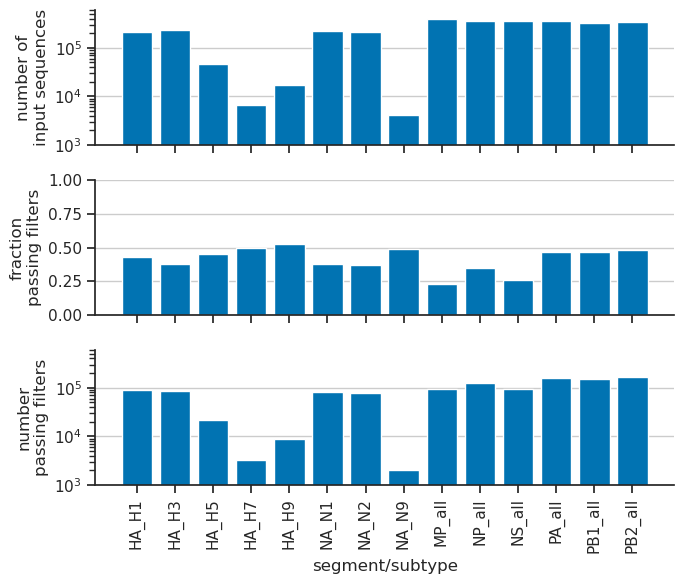

In [16]:
# Create three subplots: total number (top), fraction passed (middle), number passed on log scale (bottom)
fig, axes = plt.subplots(3, 1, figsize=(7, 6), sharex=True)

# Define custom order: HA segments first, then NA segments, then the rest
ha_segments = sorted([s for s in nseqs_df['segment_subtype'] if s.startswith('HA_')])
na_segments = sorted([s for s in nseqs_df['segment_subtype'] if s.startswith('NA_')])
other_segments = sorted([s for s in nseqs_df['segment_subtype'] if not s.startswith('HA_') and not s.startswith('NA_')])
segment_order = ha_segments + na_segments + other_segments
nseqs_df_ordered = nseqs_df.set_index('segment_subtype').loc[segment_order].reset_index()

x = range(len(nseqs_df_ordered))

# Top subplot: total number
axes[0].bar(x, nseqs_df_ordered['total'])
axes[0].set_ylabel('number of\ninput sequences')
axes[0].set_yscale('log')
axes[0].set_ylim([1e3, 6e5])

# Middle subplot: fraction passed
axes[1].bar(x, nseqs_df_ordered['frac_passed'])
axes[1].set_ylabel('fraction\npassing filters')
axes[1].set_ylim(0, 1)

# Bottom subplot: number passed (log scale)
axes[2].bar(x, nseqs_df_ordered['passed'])
axes[2].set_yscale('log')
axes[2].set_ylim([1e3, 6e5])
axes[2].set_ylabel('number\npassing filters')
axes[2].set_xlabel('segment/subtype')

# Set x-tick labels
axes[2].set_xticks(x)
axes[2].set_xticklabels(nseqs_df_ordered['segment_subtype'], rotation=90)

# Despine all subplots and add horizontal grid lines
for ax in axes:
    sns.despine(ax=ax)
    ax.yaxis.grid(True)

plt.tight_layout()

For each curated alignment, record the percent amino-acid identity of each sequence relative to the alignment's reference sequence (the first sequence in each alignment).

In [9]:
# Calculate percent amino acid identity for each sequence relative to reference
import random

identity_data = []

for segment in segment_dirs:
    subtype_dirs = [d for d in os.listdir(f'../logs/{segment}/') if os.path.isdir(os.path.join(f'../logs/{segment}/', d))]
    for subtype in subtype_dirs:
        
        print(segment, subtype)
        
        # Read alignment
        alignment_file = f'../results/{segment}/{subtype}/curated_msa.fasta.xz'
        with lzma.open(alignment_file, 'rt') as f:
            sequences = list(SeqIO.parse(f, 'fasta'))
        
        # Subset to 1000 randomly selected sequences (keep reference as first)
        if len(sequences) > 1001:
            sequences = [sequences[0]] + random.sample(sequences[1:], 1000)
        
        # First sequence is the reference
        ref_seq = str(sequences[0].seq)
        ref_length = len(ref_seq)
        
        # Calculate identity for each sequence (excluding reference itself)
        for i, seq_record in enumerate(sequences[1:], start=1):
            seq = str(seq_record.seq)
            pct_identity = sum([x == y for x, y in zip(ref_seq, seq)]) / ref_length * 100
            
            identity_data.append({
                'segment_subtype': f'{segment}_{subtype}',
                'sequence_id': seq_record.id,
                'percent_identity': pct_identity,
            })

identity_df = pd.DataFrame(identity_data)
print(f"Analyzed {len(identity_df)} sequences across {identity_df['segment_subtype'].nunique()} segment-subtype combinations")
identity_df.head(10)

PB2 all
NP all
PB1 all
NS all
PA all
NA N2
NA N9
NA N1
MP all
HA H3
HA H1
HA H9
HA H7
HA H5
Analyzed 14000 sequences across 14 segment-subtype combinations


,segment_subtype,sequence_id,percent_identity
0,PB2_all,EPI_ISL_280891,82.149123
1,PB2_all,EPI_ISL_17804606,91.447368
2,PB2_all,EPI_ISL_346430,84.166667
3,PB2_all,EPI_ISL_18054145,91.403509
4,PB2_all,EPI_ISL_19823699,91.359649
5,PB2_all,EPI_ISL_19011551,91.535088
6,PB2_all,EPI_ISL_19792087,91.535088
7,PB2_all,EPI_ISL_113308,81.447368
8,PB2_all,EPI_ISL_19552462,83.947368
9,PB2_all,EPI_ISL_12710446,91.535088


Plot the distribution of percent amino-acid identities for each segment-subtype combination.

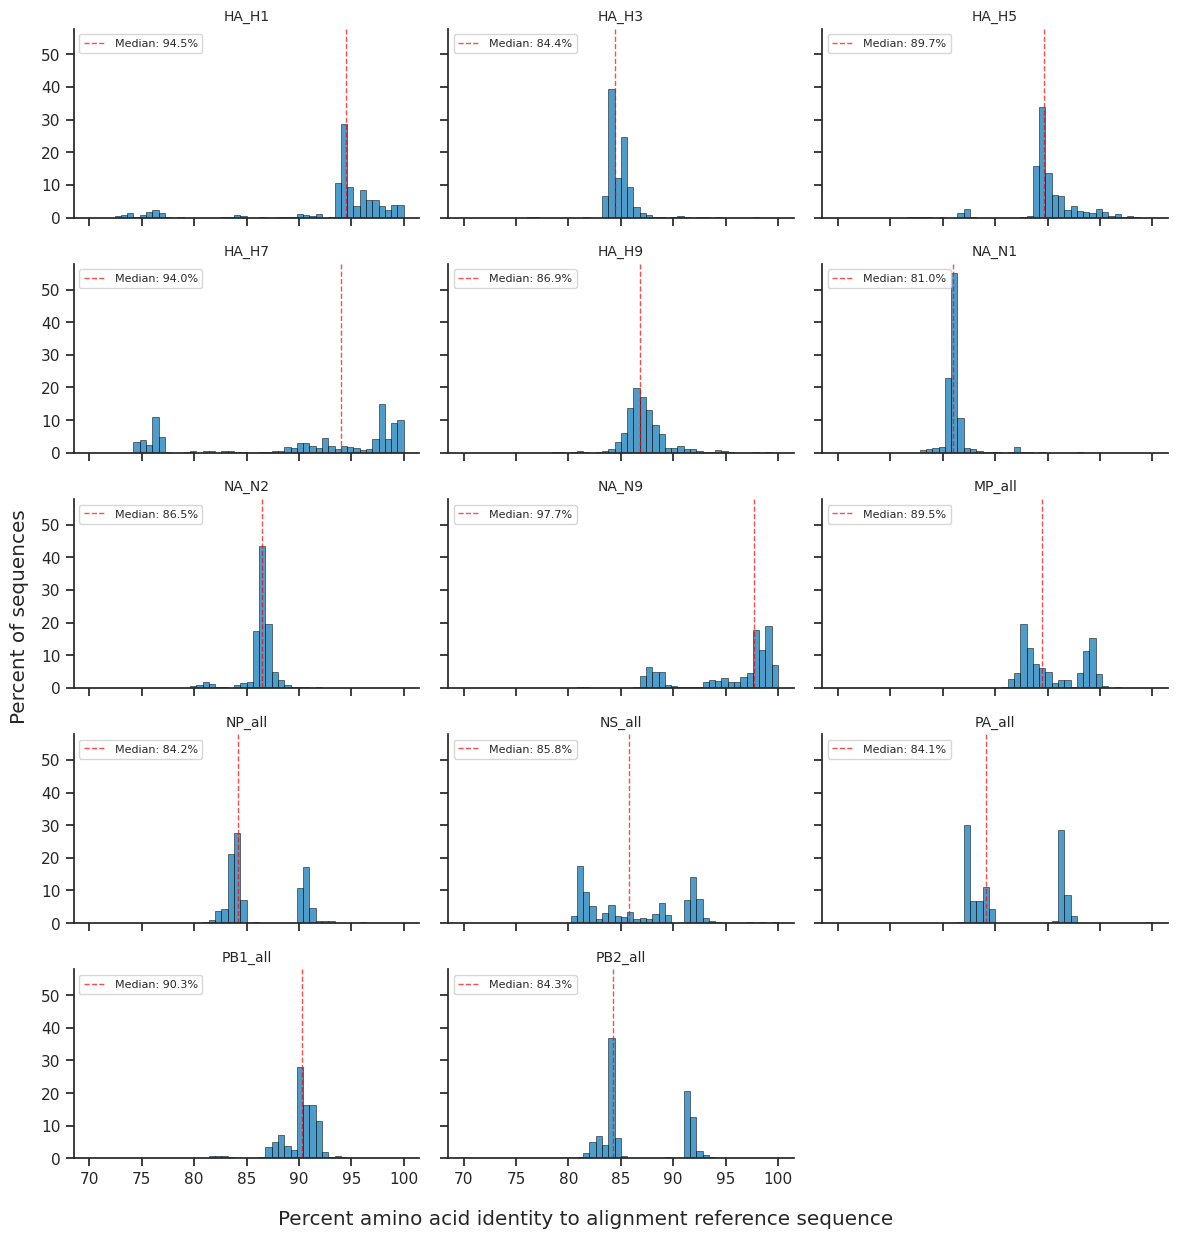

In [13]:
# Get unique segment-subtypes and order them
segment_subtypes = identity_df['segment_subtype'].unique()

# Use the same ordering as before
ha_segments = sorted([s for s in segment_subtypes if s.startswith('HA_')])
na_segments = sorted([s for s in segment_subtypes if s.startswith('NA_')])
other_segments = sorted([s for s in segment_subtypes if not s.startswith('HA_') and not s.startswith('NA_')])
ordered_segments = ha_segments + na_segments + other_segments

# Create subplots with shared axes
n_segments = len(ordered_segments)
n_cols = 3
n_rows = (n_segments + n_cols - 1) // n_cols  # Ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows * 2.5), sharex=True, sharey=True)
axes = axes.flatten() if n_segments > 1 else [axes]

# Define common bins for all histograms
bins = np.linspace(70, 100, 51)

for idx, segment_subtype in enumerate(ordered_segments):
    ax = axes[idx]
    
    # Get data for this segment-subtype
    data = identity_df[identity_df['segment_subtype'] == segment_subtype]['percent_identity']
    
    # Plot histogram with common bins, using weights to show percentages
    weights = np.ones(len(data)) / len(data) * 100
    ax.hist(data, bins=bins, weights=weights, alpha=0.7, edgecolor='black', linewidth=0.5)
    ax.set_title(segment_subtype, fontsize=10)
    
    # Add median statistic
    median_val = data.median()
    ax.axvline(median_val, color='red', linestyle='--', linewidth=1, alpha=0.7, label=f'Median: {median_val:.1f}%')
    ax.legend(fontsize=8, loc='upper left')
    
    # Add horizontal grid lines
    ax.yaxis.grid(True, linestyle='-', alpha=0.3)
    
    sns.despine(ax=ax)

# Hide any unused subplots
for idx in range(n_segments, len(axes)):
    axes[idx].axis('off')

# Set common axis labels on outer subplots only
fig.supxlabel('Percent amino acid identity to alignment reference sequence')
fig.supylabel('Percent of sequences')

plt.tight_layout()
plt.show()